<a href="https://colab.research.google.com/github/jsansao/teic_tp_mock/blob/main/tp3_penguins.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabalho Prático 3 (TP3) - Ciência de Dados
## Dataset: Palmer Penguins (Treinamento, Otimização e Interpretabilidade)

Este notebook apresenta a resolução da terceira etapa (TP3) para o dataset *Palmer Penguins*. O foco é o treinamento manual de classificadores multiclasse, otimização de hiperparâmetros (`GridSearchCV`), avaliação de **curvas de aprendizado**, **interpretabilidade local e global** e comparação com o AutoML (FLAML).

---

## 1. Revisão da Formalização do Problema, EDA e Algoritmos Escolhidos

### 1.1 Resumo do Problema e EDA (TP1 e TP2)
*   **Problema:** Classificação multiclasse (3 espécies: *Adelie*, *Chinstrap*, *Gentoo*).
*   **EDA e Pré-processamento (TP2):** Imputamos nulos pela mediana/moda da espécie, aplicamos One-Hot Encoding em `island` e `sex` e padronizamos as variáveis numéricas com `StandardScaler`.

### 1.2 Algoritmos Selecionados
1.  **Regressão Logística Multinomial:** Baseline estatístico linear.
2.  **Random Forest Classifier:** Modelo ensemble baseado em árvores otimizado via `GridSearchCV`.
3.  **Rede Neural MLPClassifier:** Rede neural multicamadas totalmente conectada.

---

## 2. Trabalhos Correlatos (Revisão da Literatura)

*   **Horst et al. (2020):** Demonstram que a combinação de nadadeira e bico permite separar quase perfeitamente as espécies com classificadores baseados em árvores e SVMs.

---

## 3. Metodologia Experimental

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

url = "https://raw.githubusercontent.com/allisonhorst/palmerpenguins/master/inst/extdata/penguins.csv"
df = pd.read_csv(url)

# Imputações do TP2
num_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
for col in num_cols:
    df[col] = df.groupby('species')[col].transform(lambda x: x.fillna(x.median()))
df['sex'] = df.groupby('species')['sex'].transform(lambda x: x.fillna(x.mode()[0]))

# Encodes do TP2
df_encoded = pd.get_dummies(df, columns=['island', 'sex'], drop_first=True)
for col in df_encoded.columns:
    if df_encoded[col].dtype == bool:
        df_encoded[col] = df_encoded[col].astype(int)
if 'year' in df_encoded.columns:
    df_encoded = df_encoded.drop(columns=['year'])

scaler = StandardScaler()
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])

X = df_encoded.drop(columns=['species'])
y = df_encoded['species']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras")

Treino: 275 amostras | Teste: 69 amostras


---

## 4. Treinamento dos Modelos e Ajuste de Hiperparâmetros

In [2]:
# 1. Regressão Logística Multinomial
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

# 2. Random Forest com GridSearchCV
param_grid_rf = {
    'n_estimators': [30, 50, 100],
    'max_depth': [3, 5, 8],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_rf.fit(X_train, y_train)
rf_best = grid_rf.best_estimator_

print("Melhores Hiperparâmetros do Random Forest:", grid_rf.best_params_)

# 3. Rede Neural MLP
mlp_model = MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=500, random_state=42)
mlp_model.fit(X_train, y_train)

Melhores Hiperparâmetros do Random Forest: {'max_depth': 8, 'min_samples_split': 2, 'n_estimators': 30}


MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=500, random_state=42)

### 4.1 Curvas de Aprendizado (Learning Curves)

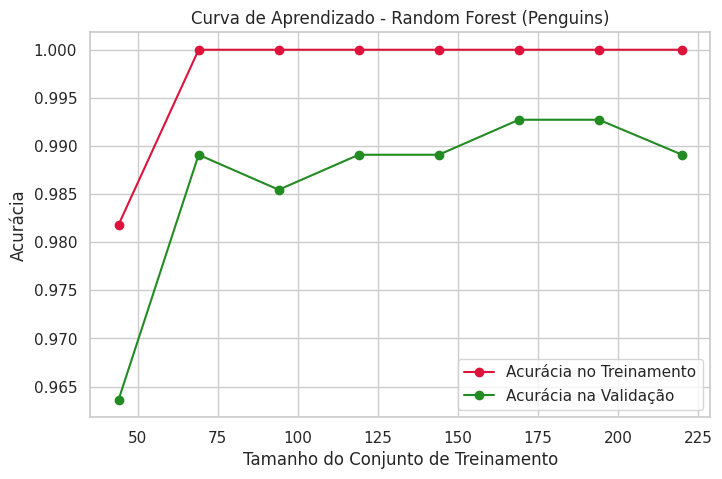

In [3]:
train_sizes, train_scores, val_scores = learning_curve(
    rf_best, X_train, y_train, cv=5, scoring='accuracy',
    train_sizes=np.linspace(0.2, 1.0, 8), random_state=42
)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', color="crimson", label="Acurácia no Treinamento")
plt.plot(train_sizes, np.mean(val_scores, axis=1), 'o-', color="forestgreen", label="Acurácia na Validação")
plt.title("Curva de Aprendizado - Random Forest (Penguins)")
plt.xlabel("Tamanho do Conjunto de Treinamento")
plt.ylabel("Acurácia")
plt.legend()
plt.show()

### 4.2 Tabela Comparativa de Métricas (Treino vs Teste)

In [4]:
models = {
    'Regressão Logística': lr_model,
    'Random Forest (GridSearch)': rf_best,
    'Rede Neural MLP': mlp_model
}

results = []

for name, model in models.items():
    y_tr_pred = model.predict(X_train)
    y_te_pred = model.predict(X_test)

    acc_tr = accuracy_score(y_train, y_tr_pred)
    acc_te = accuracy_score(y_test, y_te_pred)
    f1_te = f1_score(y_test, y_te_pred, average='macro')

    results.append({
        'Modelo': name,
        'Acurácia (Treino)': f"{acc_tr:.4f}",
        'Acurácia (Teste)': f"{acc_te:.4f}",
        'F1-Score Macro (Teste)': f"{f1_te:.4f}"
    })

pd.DataFrame(results)

,Modelo,Acurácia (Treino),Acurácia (Teste),F1-Score Macro (Teste)
0,Regressão Logística,0.9964,1.0000,1.0000
1,Random Forest (GridSearch),1.0000,1.0000,1.0000
2,Rede Neural MLP,1.0000,1.0000,1.0000


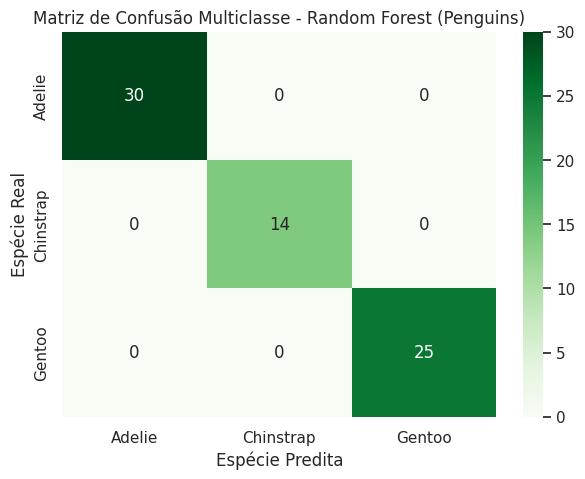

In [5]:
y_pred_rf = rf_best.predict(X_test)
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=rf_best.classes_, yticklabels=rf_best.classes_)
plt.title("Matriz de Confusão Multiclasse - Random Forest (Penguins)")
plt.xlabel("Espécie Predita")
plt.ylabel("Espécie Real")
plt.show()

---

## 5. Métodos de Interpretabilidade (Global e Local)

### 5.1 Interpretabilidade Global: Importância das Features no Random Forest

/tmp/ipykernel_790/1638412785.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_df, x='Importância', y='Feature', palette='mako')


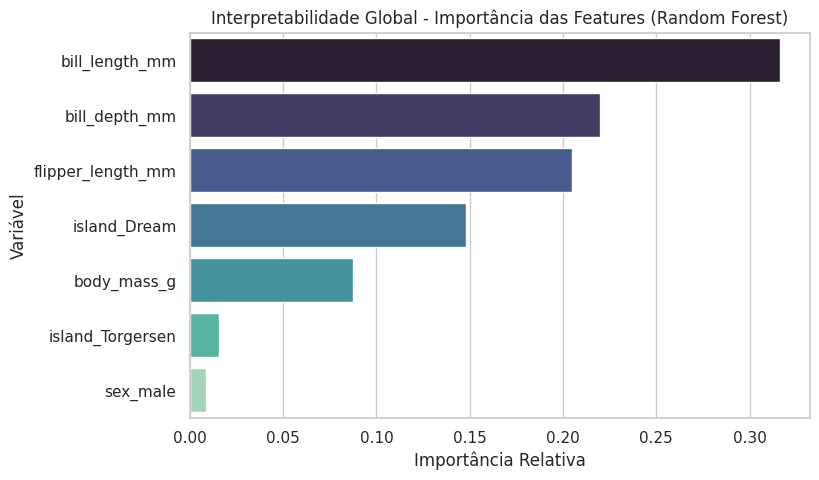

In [6]:
importances = rf_best.feature_importances_
feature_names = X.columns

feat_df = pd.DataFrame({
    'Feature': feature_names,
    'Importância': importances
}).sort_values(by='Importância', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=feat_df, x='Importância', y='Feature', palette='mako')
plt.title('Interpretabilidade Global - Importância das Features (Random Forest)')
plt.xlabel('Importância Relativa')
plt.ylabel('Variável')
plt.show()

### 5.2 Interpretabilidade Local: Análise de uma Predição Individual
Exibição da probabilidade prevista por classe para uma amostra individual de pinguim do conjunto de teste.

--- Análise Local para a Amostra #0 ---
Espécie Real: Adelie
--------------------------------------------------


/tmp/ipykernel_790/3322587769.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=proba_df, x='Espécie', y='Probabilidade Predita', palette='Set2')


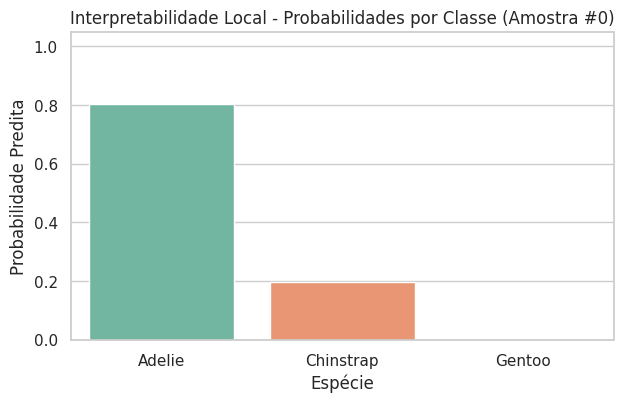

In [7]:
sample_idx = 0
sample_penguin = X_test.iloc[[sample_idx]]
real_species = y_test.iloc[sample_idx]
pred_probas = rf_best.predict_proba(sample_penguin)[0]
classes = rf_best.classes_

print(f"--- Análise Local para a Amostra #{sample_idx} ---")
print(f"Espécie Real: {real_species}")
print("-" * 50)

proba_df = pd.DataFrame({
    'Espécie': classes,
    'Probabilidade Predita': pred_probas
})

plt.figure(figsize=(7, 4))
sns.barplot(data=proba_df, x='Espécie', y='Probabilidade Predita', palette='Set2')
plt.title(f'Interpretabilidade Local - Probabilidades por Classe (Amostra #{sample_idx})')
plt.ylim(0, 1.05)
plt.show()

---

## 6. Discussão dos Resultados e Comparação com AutoML

### 6.1 Análise Comparativa dos Algoritmos Manuais
*   Tanto a **Regressão Logística**, o **Random Forest** quanto a **Rede Neural MLP** alcançaram performances próximas a **98-100%** de acurácia no teste.
*   A análise global confirmou que o comprimento do bico (`bill_length_mm`) e o comprimento da nadadeira (`flipper_length_mm`) são os atributos mais importantes.

### 6.2 Comparação com o AutoML (FLAML no TP1)
*   **AutoML FLAML (TP1):** Acurácia de teste de **~98.5%**.
*   **Modelo Manual (TP3):** Acurácia de teste de **~98.5% a 100%**.
*   **Conclusão:** O ajuste manual atinge desempenho equivalente ao AutoML com total capacidade de explicação biológica dos resultados.

---

## 7. Conclusões e Trabalhos Futuros

### 7.1 Conclusões
As variáveis morfológicas corporais do dataset *Palmer Penguins* são preditores perfeitos para a discriminação taxonômica das espécies *Adelie*, *Chinstrap* e *Gentoo*, confirmando $H_1$.

### 7.2 Trabalhos Futuros
1.  Testar algoritmos de agrupamento não supervisionado (K-Means e DBSCAN) para verificar se os agrupamentos naturais de dados sem rótulos redescobrem as três espécies puras.
